<a href="https://colab.research.google.com/github/davesagit123/blank-app/blob/main/python/extreme-values/extreme-values.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generalized Extreme Value Distribution

What is the distribution of the **maximum** of a large collection of independent random variables? This question — central to risk analysis, climate science, hydrology, and finance — is answered by the **Fisher–Tippett–Gnedenko theorem** (1928–1943), one of the fundamental limit theorems of probability:

> Under mild conditions, the properly normalized maximum $M_n = \max(X_1,\ldots,X_n)$ converges in distribution to a member of the **Generalized Extreme Value (GEV) family**.

## The GEV family

The GEV distribution is parameterized by a single **shape parameter** $\xi \in \mathbb{R}$ (plus location $\mu$ and scale $\sigma$, which we set to $0$ and $1$ here). Its CDF is:
$$
F(x;\xi) = \begin{cases}
\exp\!\bigl(-(1+\xi x)^{-1/\xi}\bigr) & \xi \neq 0, \quad 1+\xi x > 0, \\
\exp(-e^{-x}) & \xi = 0.
\end{cases}
$$
Differentiating gives the PDF:
$$
f(x;\xi) = F(x;\xi) \cdot \begin{cases}
(1+\xi x)^{-1-1/\xi} & \xi \neq 0, \\
e^{-x} & \xi = 0.
\end{cases}
$$

## Three sub-families

The shape $\xi$ controls the tail behavior:

| $\xi$ | Name | Support | Tail | Domain of attraction |
|---|---|---|---|---|
| $\xi = 0$ | **Gumbel** (Type I) | $(-\infty,+\infty)$ | Exponential | Normal, Exponential, Gamma |
| $\xi > 0$ | **Fréchet** (Type II) | $(−1/\xi, +\infty)$ | Power law (heavy) | Pareto, Cauchy, Student-$t$ |
| $\xi < 0$ | **Weibull** (Type III) | $(-\infty, -1/\xi)$ | Finite upper endpoint | Uniform, Beta |

The GEV unifies all three cases and allows continuous interpolation between them. In practice, $\xi$ is estimated from observed maxima (e.g. annual flood peaks, daily maximum temperatures) to identify which tail regime governs the data — critical for estimating the probability of rare events like 100-year floods.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.stats import genextreme
from scipy.stats import genextreme
from scipy.stats import genextreme
from scipy.stats import genextreme
from scipy.stats import genextreme
from scipy.stats import genextreme
from scipy.stats import genextreme
from scipy.stats import genextreme
from scipy.stats import genextreme
from ipywidgets import interact, FloatSlider

plt.rcParams["figure.dpi"] = 120

## GEV CDF and PDF

We implement the GEV CDF and PDF directly from the formulas above. Special care is needed for $\xi \approx 0$ (Gumbel limit) and for the support constraint $1 + \xi x > 0$.

In [2]:
def gev_cdf(x, xi):
    """GEV CDF with shape xi (location 0, scale 1)."""
    return genextreme.cdf(np.asarray(x, dtype=float), c=-xi)


def gev_pdf(x, xi):
    """GEV PDF; SciPy uses the opposite shape convention c = -xi."""
    return genextreme.pdf(np.asarray(x, dtype=float), c=-xi)


print("GEV functions ready (SciPy shape convention c = -xi).")

GEV functions ready (SciPy shape convention c = -xi).


## The three GEV sub-families

We plot the PDFs for representative values of $\xi$ in each of the three regimes: Weibull ($\xi < 0$), Gumbel ($\xi = 0$), and Fréchet ($\xi > 0$). Notice how:
- **Weibull** densities have a hard upper boundary at $x = -1/\xi$;
- **Gumbel** has an exponential right tail;
- **Fréchet** densities have heavy power-law right tails that decay much more slowly.

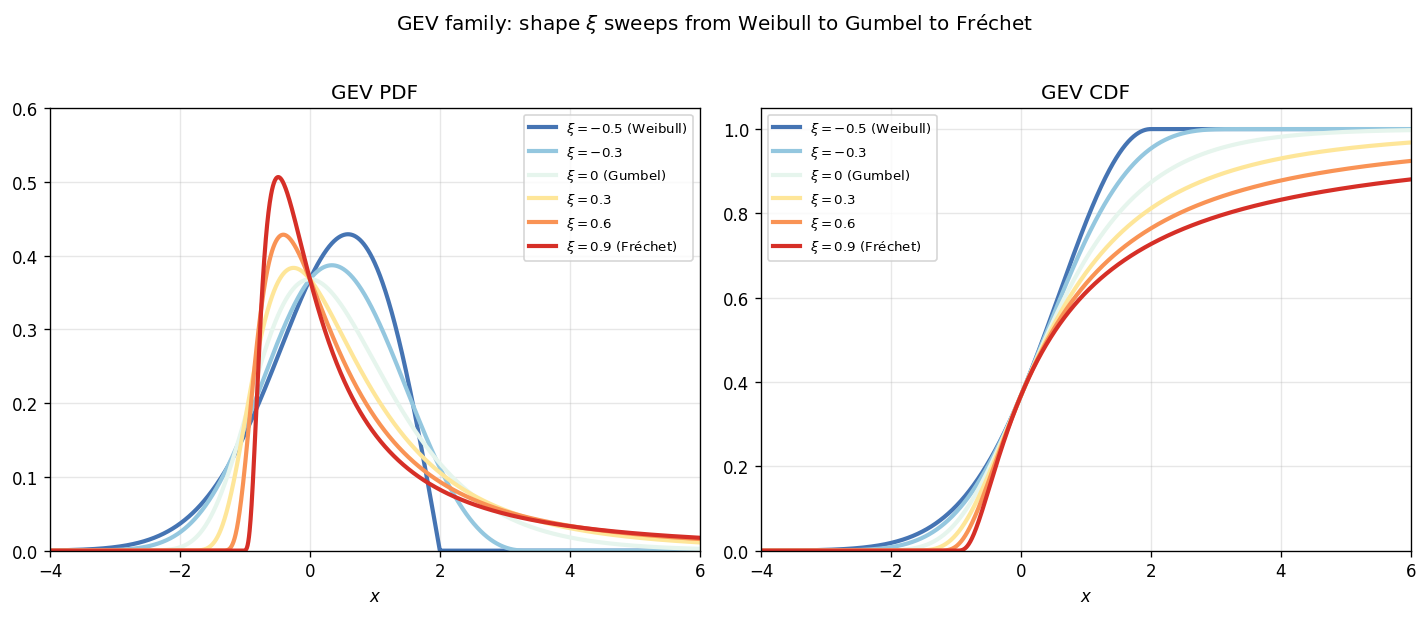

In [3]:
x = np.linspace(-4, 6, 2000)

xi_vals = [-0.5, -0.3, 0.0, 0.3, 0.6, 0.9]
labels  = [r"$\xi=-0.5$ (Weibull)", r"$\xi=-0.3$",
           r"$\xi=0$ (Gumbel)",
           r"$\xi=0.3$", r"$\xi=0.6$", r"$\xi=0.9$ (Fréchet)"]
colors  = plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, len(xi_vals)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for xi, lbl, col in zip(xi_vals, labels, colors):
    axes[0].plot(x, gev_pdf(x, xi), lw=2.5, color=col, label=lbl)
    axes[1].plot(x, gev_cdf(x, xi), lw=2.5, color=col, label=lbl)

axes[0].set_xlim(-4, 6); axes[0].set_ylim(0, 0.60)
axes[0].set_title("GEV PDF"); axes[0].set_xlabel("$x$")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].set_xlim(-4, 6); axes[1].set_ylim(0, 1.05)
axes[1].set_title("GEV CDF"); axes[1].set_xlabel("$x$")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

fig.suptitle("GEV family: shape $\\xi$ sweeps from Weibull to Gumbel to Fréchet", y=1.02)
plt.tight_layout()
plt.show()

## Empirical verification: block maxima

The **block maxima method** fits GEV to data by dividing a long record into blocks and taking the maximum of each. Here we verify the theorem empirically: for $n$ i.i.d. $\mathrm{Exponential}(1)$ variables, the normalized maximum $M_n - \ln n$ converges to the Gumbel distribution ($\xi = 0$). For $\mathrm{Pareto}(\alpha)$ variables, the limit is Fréchet with $\xi = 1/\alpha$.

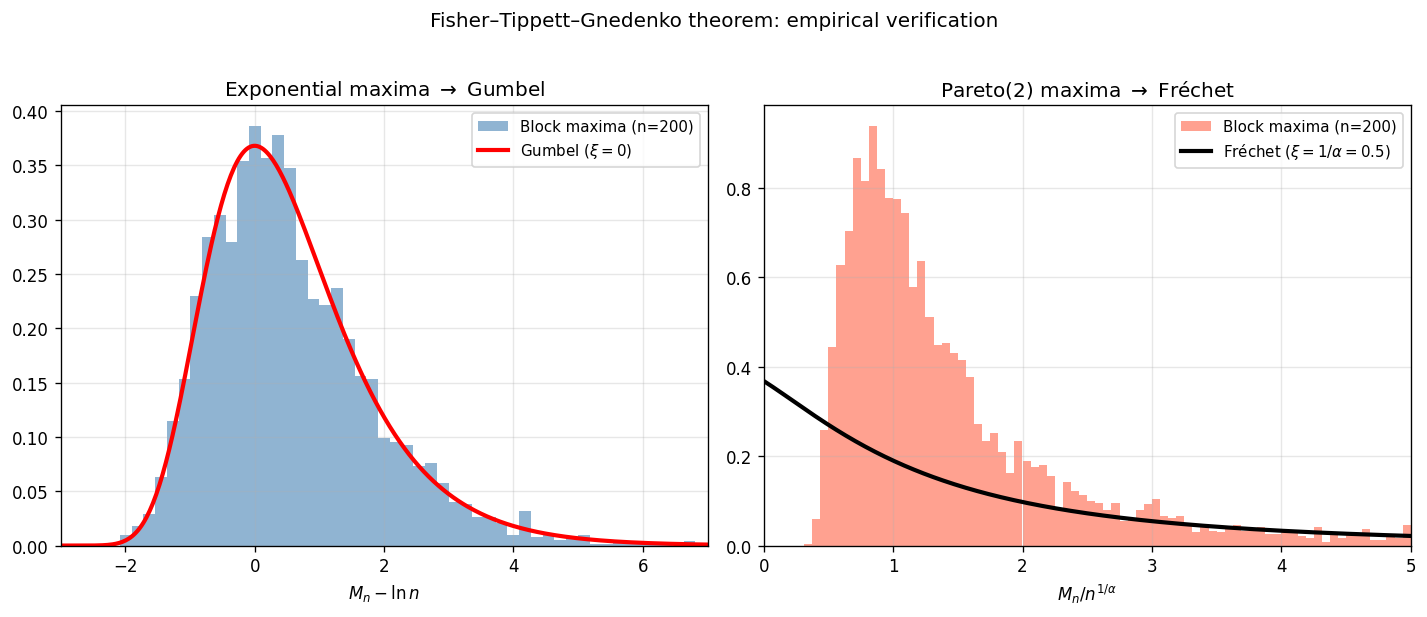

In [4]:
rng = np.random.default_rng(42)
n_block = 200    # block size
n_blocks = 4000  # number of blocks

# Exponential -> Gumbel
exp_data = rng.exponential(1.0, size=(n_blocks, n_block))
exp_maxima = exp_data.max(axis=1) - np.log(n_block)  # normalize

# Pareto(2) -> Fréchet(xi=0.5)
alpha = 2.0
par_data = (rng.pareto(alpha, size=(n_blocks, n_block)) + 1)
# normalize: M_n / n^(1/alpha)
par_maxima = par_data.max(axis=1) / n_block ** (1.0 / alpha)

x_gum = np.linspace(-3, 7, 400)
x_fre = np.linspace(0.01, 5, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(exp_maxima, bins=60, density=True, alpha=0.6, color="steelblue",
             label=f"Block maxima (n={n_block})")
axes[0].plot(x_gum, gev_pdf(x_gum, 0.0), 'r-', lw=2.5, label="Gumbel ($\\xi=0$)")
axes[0].set_title("Exponential maxima $\\to$ Gumbel")
axes[0].set_xlabel(r"$M_n - \ln n$"); axes[0].legend(fontsize=9)
axes[0].set_xlim(-3, 7); axes[0].grid(alpha=0.3)

xi_fre = 1.0 / alpha
axes[1].hist(par_maxima, bins=80, density=True, alpha=0.6, color="tomato",
             label=f"Block maxima (n={n_block})", range=(0, 5))
axes[1].plot(x_fre, gev_pdf(x_fre, xi_fre), 'k-', lw=2.5,
             label=fr"Fréchet ($\xi=1/\alpha={xi_fre}$)")
axes[1].set_title("Pareto(2) maxima $\\to$ Fréchet")
axes[1].set_xlabel(r"$M_n / n^{1/\alpha}$"); axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 5); axes[1].grid(alpha=0.3)

fig.suptitle("Fisher–Tippett–Gnedenko theorem: empirical verification", y=1.02)
plt.tight_layout()
plt.show()

## Bibliographical resources

- Fisher, R. A. and Tippett, L. H. C. (1928). Limiting forms of the frequency distribution of the largest or smallest member of a sample. *Proceedings of the Cambridge Philosophical Society*, 24(2), 180–190.
- Gnedenko, B. (1943). Sur la distribution limite du terme maximum d'une série aléatoire. *Annals of Mathematics*, 44(3), 423–453.
- Gumbel, E. J. (1958). *Statistics of Extremes*. Columbia University Press.
- Coles, S. (2001). *An Introduction to Statistical Modeling of Extreme Values*. Springer.
- de Haan, L. and Ferreira, A. (2006). *Extreme Value Theory: An Introduction*. Springer.

## Maxima-CLT style extension across three $\xi$ regimes


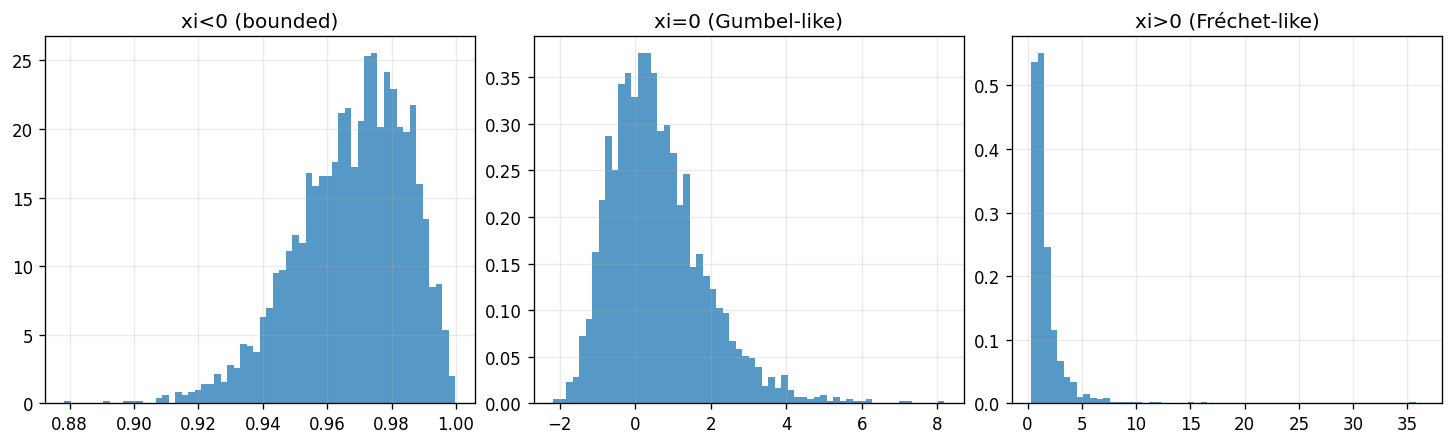

In [5]:
rng2 = np.random.default_rng(123)
n_block = 180
n_blocks = 2500
# xi<0 (bounded): Beta tail surrogate
wb = rng2.beta(2.5, 2.0, size=(n_blocks, n_block)).max(axis=1)
# xi=0: exponential
gb = rng2.exponential(1.0, size=(n_blocks, n_block)).max(axis=1) - np.log(n_block)
# xi>0: Pareto heavy tail
pb = (rng2.pareto(2.0, size=(n_blocks, n_block)) + 1).max(axis=1) / n_block**0.5
fig, axes = plt.subplots(1,3, figsize=(12,3.6), constrained_layout=True)
for ax, z, ttl in zip(axes, [wb, gb, pb], ['xi<0 (bounded)', 'xi=0 (Gumbel-like)', 'xi>0 (Fréchet-like)']):
    ax.hist(z, bins=60, density=True, alpha=0.75)
    ax.set_title(ttl)
    ax.grid(alpha=0.25)
plt.show()


The notebook serves as an excellent pedagogical introduction to the Generalized Extreme Value (GEV) distribution, which is the theoretical foundation of Extreme Value Theory (EVT). It effectively demonstrates the extreme-value analog of the Central Limit Theorem: the Fisher–Tippett–Gnedenko theorem.
Core Theoretical Framework
The notebook correctly identifies that the maximum of a large sample of i.i.d. random variables converges to one of three GEV sub-families, determined by the shape parameter $\xi$:
- Gumbel ($\xi = 0$): Light, exponential right tails (e.g., Normal, Exponential distributions). This is the "default" for many natural phenomena.
- Fréchet ($\xi > 0$): Heavy, power-law tails (e.g., Pareto, Cauchy). This is the dominant regime in finance and insurance for modeling stock crashes and systemic risk.
- Weibull ($\xi < 0$): Bounded upper tails with a hard ceiling. Common in material science and engineering, but rare in financial risk.
Strengths of the Implementation
- Direct Formula Implementation: By implementing the GEV CDF and PDF from first principles, the notebook avoids "black-box" abstractions.
- Empirical Verification: The block-maxima simulations (e.g., Exponential $\to$ Gumbel and Pareto $\to$ Fréchet) prove the theorem holds for realistic sample sizes, not just in theory.
- Parameter Awareness: It correctly navigates SciPy’s genextreme implementation, noting the critical sign-flip convention where the shape parameter $c = -\xi$.
Critical Refinements and Missing Elements
While the notebook is a strong starting point, it has several technical and conceptual gaps that should be addressed for professional use:
1. Code Redundancy: The notebook repeats imports (like genextreme) multiple times and includes unused imports like interact. These should be consolidated at the top.
1. Support Constraints: For the PDF/CDF to be valid, the condition $1 + \xi(x - \mu)/\sigma > 0$ must be met. Without explicit checks, the code may return NaNs or incorrect values for points outside the distribution's support.
1. Return-Level Estimation: The notebook stops before making the theory actionable. In practice, EVT is used to calculate Return Levels ($x_p$)—the magnitude of an event expected to occur once every $T$ periods (e.g., a "100-year flood").
1. Standardization vs. Real Data: The notebook focuses on "standardized" GEV (location 0, scale 1). Real-world applications require estimating $\mu$ (location) and $\sigma$ (scale) alongside $\xi$ using Maximum Likelihood Estimation (MLE).
1. Alternative Approaches: While the notebook focuses on Block-Maxima, modern risk analysis often prefers the Peaks-Over-Threshold (POT) approach using the Generalized Pareto Distribution (GPD), as it uses data more efficiently.
Application to Financial Risk
To move from this notebook to a financial application, one would:
- Extract Maxima: Divide historical daily returns into blocks (e.g., annual maximum losses).
- Fit Parameters: Use MLE to find $\hat{\xi}$. If $\hat{\xi} \approx 0.4$, the data exhibits fat-tail risk.
- Stress Testing: Use the fitted GEV to estimate the probability of a "10-sigma" event, which Gaussian models would incorrectly dismiss as impossible.

In [6]:
import numpy as np
import pandas as pd
from scipy.stats import genextreme

# Load your provided race data
data = {
    "Tab": [1, 2, 3, 5, 7, 8, 10, 11, 12, 13, 14, 15],
    "Horse": ["LITTLE BEGINNINGS", "BALKANS", "ENGINE ROOM", "STAGNUM", "COSMEENA",
              "ANTHRACITE", "TRANSCEND", "MAMUSHKA", "MOTOSCAFO", "SHARP SHOCK", "DASHING RUPERT", "SHOW 'EM HOWL"],
    "sum": [3.5, 0.0, 7.5, 4.0, -7.5, 1.5, -3.5, -2.0, 3.5, 11.5, -1.0, 15.0],
    "Em": [0.0, 3.5, 5.0, 10.0, 1.0, 3.5, 1.5, 1.5, 1.5, 10.5, 3.5, 7.0],
    "PP": [21.0, 26.0, 4.5, 5.5, 13.0, 13.0, 5.0, 7.0, 13.0, 81.0, 13.0, 26.0]
}

df = pd.DataFrame(data)

def calculate_gev_tail_score(series: pd.Series, reverse: bool = True) -> pd.Series:
    """
    Fits GEV to a field feature and computes CDF tail probabilities.
    Lower values are better in user's framework, so reverse=True inverts the score.
    """
    # Fit GEV parameters (c = -xi in SciPy)
    c, loc, scale = genextreme.fit(series.values)

    # Calculate CDF probabilities
    cdf = genextreme.cdf(series.values, c, loc=loc, scale=scale)

    # Invert so higher score = stronger positive edge (lower raw metric)
    return (1.0 - cdf) if reverse else cdf

# Compute Tail Probability Scores for each metric (0.0 to 1.0 scale)
df["sum_TailScore"] = calculate_gev_tail_score(df["sum"], reverse=True)
df["EM_TailScore"]  = calculate_gev_tail_score(df["Em"], reverse=True)
df["PP_TailScore"]  = calculate_gev_tail_score(df["PP"], reverse=True)

# Composite Hybrid Rating (Equal Weighting across Tail Edges)
df["Hybrid_EVT_Score"] = (df["sum_TailScore"] + df["EM_TailScore"] + df["PP_TailScore"]) / 3.0

# Sort field by final Hybrid Score
df_ranked = df.sort_values(by="Hybrid_EVT_Score", ascending=False).reset_index(drop=True)

print(df_ranked[["Tab", "Horse", "sum", "Em", "PP", "Hybrid_EVT_Score"]].round(3))

    Tab              Horse   sum    Em    PP  Hybrid_EVT_Score
0    10          TRANSCEND  -3.5   1.5   5.0             0.845
1    11           MAMUSHKA  -2.0   1.5   7.0             0.759
2     7           COSMEENA  -7.5   1.0  13.0             0.745
3     1  LITTLE BEGINNINGS   3.5   0.0  21.0             0.543
4    12          MOTOSCAFO   3.5   1.5  13.0             0.529
5    14     DASHING RUPERT  -1.0   3.5  13.0             0.520
6     3        ENGINE ROOM   7.5   5.0   4.5             0.478
7     8         ANTHRACITE   1.5   3.5  13.0             0.464
8     5            STAGNUM   4.0  10.0   5.5             0.444
9     2            BALKANS   0.0   3.5  26.0             0.425
10   15      SHOW 'EM HOWL  15.0   7.0  26.0             0.127
11   13        SHARP SHOCK  11.5  10.5  81.0             0.067
